In [1]:
# Setup
import sys
sys.path.insert(0, '../')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.utils.config import get_config
from src.utils.db import get_db
from src.utils.logger import get_logger

logger = get_logger("eda")
db = get_db()
config = get_config()

print(f"Connected to environment: {config.environment}")

2026-05-15 21:06:14 [info     ] database_initialized           database=postgres host=aws-0-eu-west-1.pooler.supabase.com pool_size=10 ssl_mode=require
Connected to environment: Environment.DEVELOPMENT


In [2]:
#  Data overview

races = db.execute_dataframe("SELECT * FROM races ORDER BY year, round")
drivers = db.execute_dataframe("SELECT * FROM drivers")
constructors = db.execute_dataframe("SELECT * FROM constructors")
results = db.execute_dataframe("SELECT * FROM results")

print(f"Races: {len(races)}")
print(f"Drivers: {len(drivers)}")
print(f"Constructors: {len(constructors)}")
print(f"Results: {len(results)}")

2026-05-15 22:09:13 [debug    ] sql_query_executing            parameters={} statement='SELECT * FROM races ORDER BY year, round'
2026-05-15 22:09:13 [debug    ] database_transaction_committed
2026-05-15 22:09:14 [debug    ] sql_query_executing            parameters={} statement='SELECT * FROM drivers'
2026-05-15 22:09:15 [debug    ] database_transaction_committed
2026-05-15 22:09:15 [debug    ] sql_query_executing            parameters={} statement='SELECT * FROM constructors'
2026-05-15 22:09:16 [debug    ] database_transaction_committed
2026-05-15 22:09:16 [debug    ] sql_query_executing            parameters={} statement='SELECT * FROM results'
2026-05-15 22:09:22 [debug    ] database_transaction_committed
Races: 24
Drivers: 36
Constructors: 10
Results: 479


In [3]:
# Championship trends

championship_query = """
SELECT r.year, d.surname, SUM(res.points) as total_points
FROM results res
JOIN races r ON res.race_id = r.race_id
JOIN drivers d ON res.driver_id = d.driver_id
WHERE r.year >= 2021
GROUP BY r.year, d.surname
ORDER BY r.year, total_points DESC
"""
championship = db.execute_dataframe(championship_query)

2026-05-15 22:50:16 [debug    ] sql_query_executing            parameters={} statement='\nSELECT r.year, d.surname, SUM(res.points) as total_points\nFROM results res\nJOIN races r ON res.race_id = r.race_id\nJOIN drivers d ON res.driver_id = d.driver_id\nWHERE r.year >= 2021\nGROUP BY r.year, '
2026-05-15 22:50:17 [debug    ] database_transaction_committed


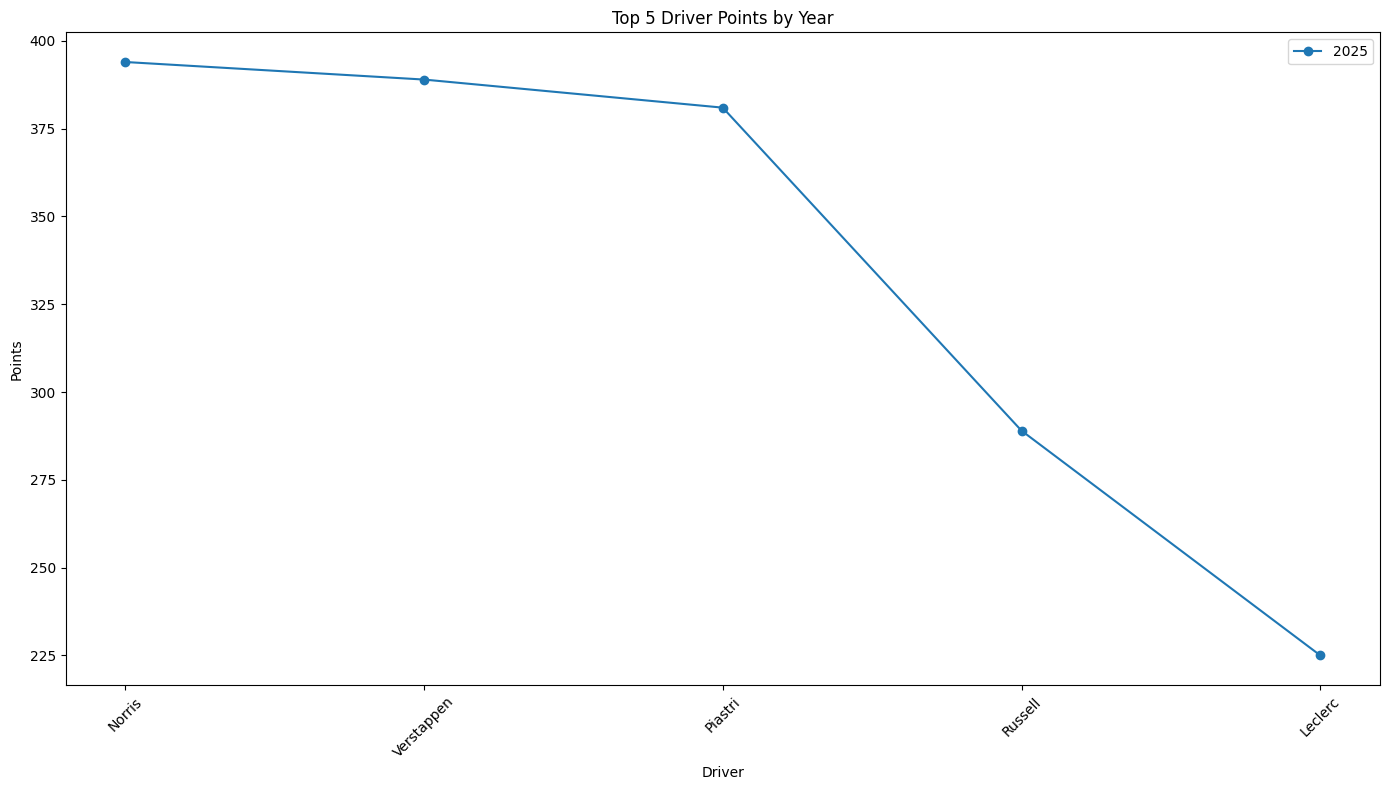

In [4]:
# Visualization

plt.figure(figsize=(14, 8))
for year in championship['year'].unique():
    year_data = championship[championship['year'] == year].head(5)
    plt.plot(year_data['surname'], year_data['total_points'],
             marker='o', label=f"{year}")
plt.title("Top 5 Driver Points by Year")
plt.xlabel("Driver")
plt.ylabel("Points")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()             

In [6]:
# Lap Time Analysis

lap_query = """
SELECT r.year, r.round, lt.lap, lt.milliseconds, d.surname
FROM lap_times lt
JOIN races r ON lt.race_id = r.race_id
JOIN drivers d ON lt.driver_id = d.driver_id
WHERE r.year = 2025 AND r.round = 1
ORDER BY lt.lap, lt.milliseconds
"""
laps = db.execute_dataframe(lap_query)

2026-05-15 23:37:29 [debug    ] sql_query_executing            parameters={} statement='\nSELECT r.year, r.round, lt.lap, lt.milliseconds, d.surname\nFROM lap_times lt\nJOIN races r ON lt.race_id = r.race_id\nJOIN drivers d ON lt.driver_id = d.driver_id\nWHERE r.year = 2025 AND r.round = 1\nOR'
2026-05-15 23:37:31 [debug    ] database_transaction_committed


In [7]:
# Feature query

feature_query = """
SELECT 
    rolling_avg_points_5r,
    recent_form_points,
    constructor_avg_points_5r,
    track_avg_points,
    quali_position,
    overall_strength_index
FROM driver_race_features
WHERE overall_strength_index IS NOT NULL
LIMIT 5000
"""
features = db.execute_dataframe(feature_query)

2026-05-15 23:39:22 [debug    ] sql_query_executing            parameters={} statement='\nSELECT \n    rolling_avg_points_5r,\n    recent_form_points,\n    constructor_avg_points_5r,\n    track_avg_points,\n    quali_position,\n    overall_strength_index\nFROM driver_race_features\nWHERE overall_'
2026-05-15 23:39:23 [debug    ] database_transaction_committed


c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


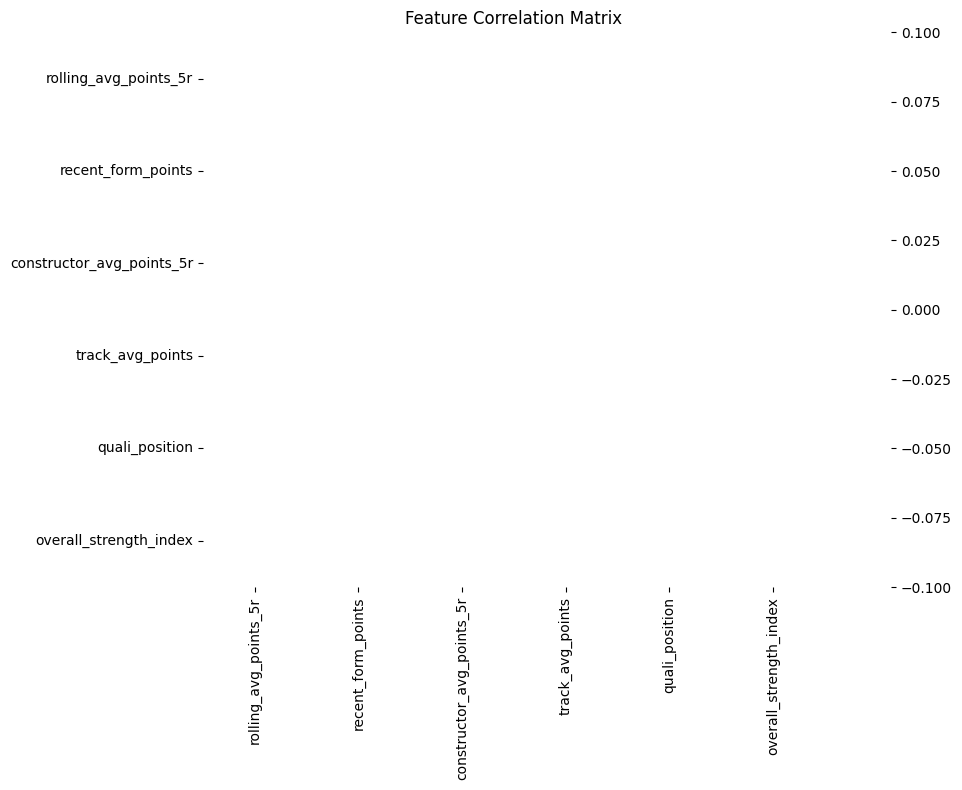

In [8]:
plt.figure(figsize=(10, 8))
sns.heatmap(features.corr(), annot=True, cmap='coolwarm', center=0)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()